## ITS Modeling

### Create copy of final df for modeling

In [4]:
# Create df for modeling
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# sort
final = pd.read_csv('teamb_final_data.csv')
final['datetime'] = pd.to_datetime(final['datetime'])
final = final.sort_values('datetime')

# aggregate monthly extreme outcome rates
final['month'] = final['datetime'].dt.to_period('M')
monthly = final.groupby('month')['extreme_cases'].mean().reset_index()

### Standard ITS Model

                            OLS Regression Results                            
Dep. Variable:          extreme_cases   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     56.60
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.85e-18
Time:                        22:48:35   Log-Likelihood:                 341.61
No. Observations:                  72   AIC:                            -675.2
Df Residuals:                      68   BIC:                            -666.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0043      0.001      5.817

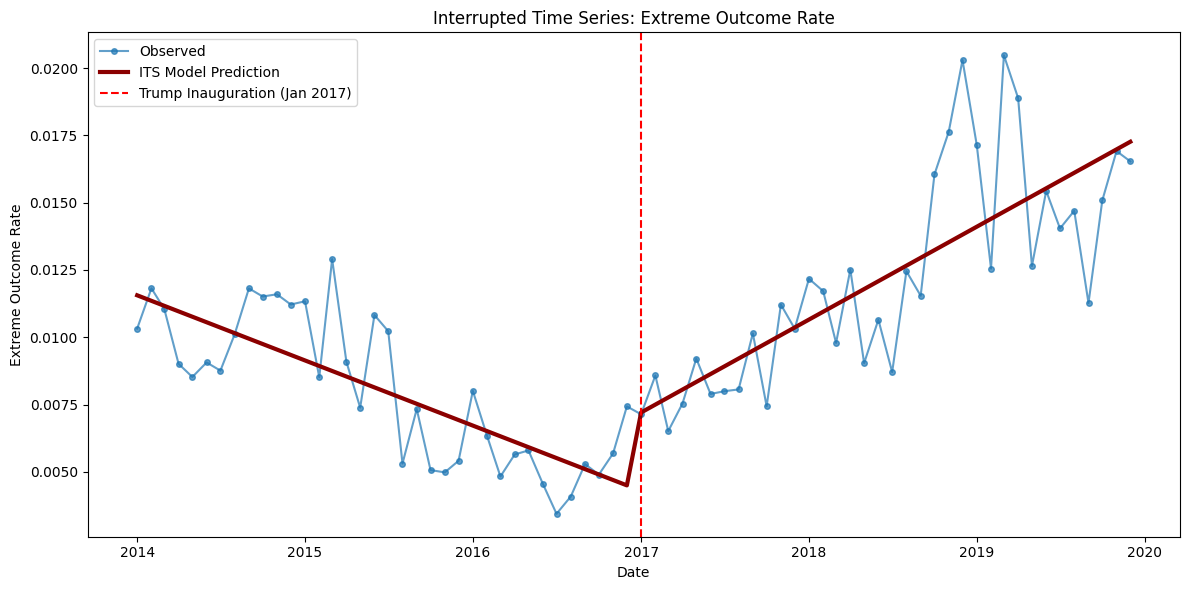

<Figure size 640x480 with 0 Axes>

In [8]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# --- Ensure month column is datetime ---
monthly['month'] = monthly['month'].dt.to_timestamp()

# --- Define intervention date ---
intervention = pd.to_datetime("2017-01-01")

# --- Create centered time variable ---
monthly['time_centered'] = (monthly['month'] - intervention).dt.days / 30

# --- Create Trump indicator ---
monthly['trump'] = (monthly['month'] >= intervention).astype(int)

# --- Create interaction term for slope change ---
monthly['time_trump'] = monthly['time_centered'] * monthly['trump']

# --- Fit interrupted time series model ---
model = smf.ols(
    'extreme_cases ~ time_centered + trump + time_trump',
    data=monthly
).fit()

print(model.summary())

# --- Generate model predictions ---
monthly['predicted'] = model.predict(monthly)

# --- Plot observed vs predicted ---
plt.figure(figsize=(12,6))

plt.plot(monthly['month'], monthly['extreme_cases'],
         marker='o', markersize=4,
         linewidth=1.5,
         alpha=0.7,
         label="Observed")

plt.plot(monthly['month'], monthly['predicted'],
         linewidth=3,
         color='darkred',
         label="ITS Model Prediction")

plt.axvline(intervention, color='red', linestyle='--', label='Trump Inauguration (Jan 2017)')

plt.title("Interrupted Time Series: Extreme Outcome Rate")
plt.xlabel("Date")
plt.ylabel("Extreme Outcome Rate")

plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('its_graph.png')

### ITS Model with Counterfactual

                            OLS Regression Results                            
Dep. Variable:          extreme_cases   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     56.60
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.85e-18
Time:                        22:49:20   Log-Likelihood:                 341.61
No. Observations:                  72   AIC:                            -675.2
Df Residuals:                      68   BIC:                            -666.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0043      0.001      5.817

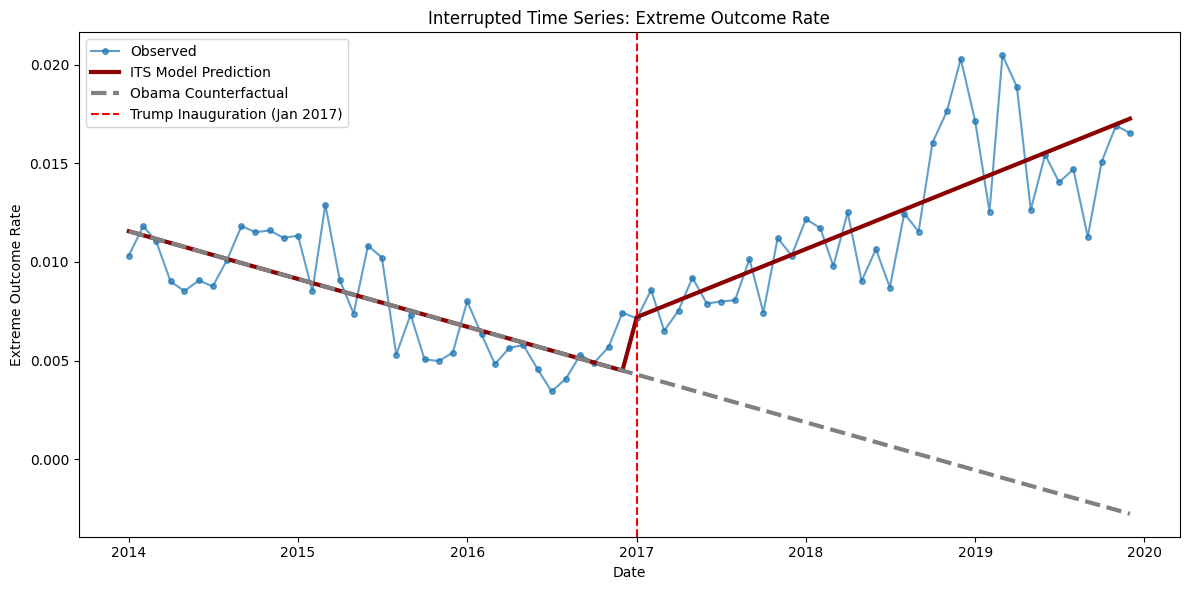

<Figure size 640x480 with 0 Axes>

In [9]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# --- Ensure month column is datetime ---
monthly['month'] = pd.to_datetime(monthly['month'])

# --- Intervention date ---
intervention = pd.to_datetime("2017-01-01")

# --- Center time at intervention ---
monthly['time_centered'] = (monthly['month'] - intervention).dt.days / 30

# --- Trump indicator ---
monthly['trump'] = (monthly['month'] >= intervention).astype(int)

# --- Slope change term ---
monthly['time_trump'] = monthly['time_centered'] * monthly['trump']

# --- Fit interrupted time series model ---
model = smf.ols(
    'extreme_cases ~ time_centered + trump + time_trump',
    data=monthly
).fit()

print(model.summary())

# --- Model predictions (actual Trump world) ---
monthly['predicted'] = model.predict(monthly)

# --- Create Obama counterfactual ---
monthly_cf = monthly.copy()
monthly_cf['trump'] = 0
monthly_cf['time_trump'] = 0

monthly['obama_counterfactual'] = model.predict(monthly_cf)

# --- Plot ---
plt.figure(figsize=(12,6))

# observed data
plt.plot(monthly['month'], monthly['extreme_cases'],
         marker='o', markersize=4,
         linewidth=1.5,
         alpha=0.7,
         label="Observed")

# model fit
plt.plot(monthly['month'], monthly['predicted'],
         linewidth=3,
         color='darkred',
         label="ITS Model Prediction")

# obama counterfactual
plt.plot(monthly['month'], monthly['obama_counterfactual'],
         linestyle="--",
         linewidth=3,
         color='gray',
         label="Obama Counterfactual")

# intervention line
plt.axvline(intervention, color='red', linestyle='--', label='Trump Inauguration (Jan 2017)')

plt.title("Interrupted Time Series: Extreme Outcome Rate")
plt.xlabel("Date")
plt.ylabel("Extreme Outcome Rate")

plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('its_graph_counterfactual.png')